# ALICE Analysis: YFV19, Ankylosing Spondylitis (AS), and MLR TCR-seq Datasets

This notebook runs a MIR implementation of ALICE (Antigen-specific Lymphocyte Identification by Clustering of Expanded sequences) on three benchmark datasets from `isalgo/airr_benchmark`. The implementation is inspired by ideas described in the ALICE paper and is not a literal line-by-line reimplementation of the original software.

- **YF (Yellow Fever vaccine)** — 6 donors × 2 time points (day 0, day 15), TRB repertoires.
- **AS (Ankylosing Spondylitis)** — 4 donors, synovial fluid CD8+ TRB repertoires.
- **MLR (Mixed Lymphocyte Reaction)** — 24 samples (fresh vs proliferating) from Adaptive immunoSEQ.

Reference: Pogorelyy MV, Minervina AA, Touzel MP, et al. *PLoS Biol.* 2019;17(6):e3000314.
doi:[10.1371/journal.pbio.3000314](https://doi.org/10.1371/journal.pbio.3000314). PMID:31194732.

**Runtime note:** Uses `N_JOBS=8` for parallel OLGA Pgen computation and trie-based neighbourhood search. `pgen_mode="1mm"` (paper-correct) is used throughout; exact pgen pre-screen skips sequences with n ≤ N×pgen_exact so only a small fraction of eligible sequences incur the expensive 1mm OLGA call.

In [1]:
"""Cell 1: Environment setup, imports, and dataset download."""
import gzip
import sys
import random
import time
import resource
import warnings
from pathlib import Path
from collections import defaultdict

import importlib.metadata
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from scipy.stats import mannwhitneyu

# Environment versions for reproducibility
print(f"Python {sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "polars", "numpy", "pandas", "matplotlib", "scipy"]:
    try:
        print(f"  {_pkg}: {importlib.metadata.version(_pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.biomarkers.alice import compute_alice, alice_hit_clusters
from mir.common.clonotype import Clonotype
from mir.common.filter import filter_functional
from mir.common.parser import AdaptiveParser, ClonotypeTableParser
from mir.common.repertoire import LocusRepertoire, infer_locus
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, ensure_airr_benchmark_alice

SEED = 42
np.random.seed(SEED)
N_JOBS = 8
# BH-FDR threshold from Pogorelyy et al. 2019 (PLoS Biol): 0.001
FDR_THRESH = 0.001
# n_neighbors counts self, so N_MIN_NEIGHBORS=2 means self + ≥1 Hamming-1 neighbour,
# matching the neighbourhood enrichment criterion from Pogorelyy et al. 2019.
N_MIN_NEIGHBORS = 2
MLR_FRESH_CAP = 300_000  # cap fresh MLR samples to keep neighbourhood search tractable
# Pgen mode — all three compute λ = N × Σ pgen(Hamming-1 neighbourhood):
#   "mc"    — MC pool of 10M synthetic seqs (paper used 1000M; increase MC_POOL_N if
#              RAM allows, ~2 GB for 10M, ~20 GB for 100M).  Pool is disk-cached via
#              ControlManager on first run; subsequent runs load from disk (fast).
#   "1mm"   — OLGA analytical 1mm pgen (~70 ms/seq). Exact but slow for >100K clonotypes.
#   "exact" — OLGA exact pgen only. Underestimates λ → inflates hit counts; NOT correct.
ALICE_PGEN_MODE = "mc"
# Pool size: original ALICE paper used 1_000_000_000. 100M is the safe default on 32 GB machines.
MC_POOL_N = 10_000_000
RAM_LIMIT_GB = 28.0  # YF+MLR reach ~26 GB peak with 10M hash pool; hardware limit 32 GB

def _rss_gb() -> float:
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e9

def _check_ram(label: str = "") -> None:
    rss = _rss_gb()
    tag = f"[{label}] " if label else ""
    flag = " *** OVER LIMIT ***" if rss > RAM_LIMIT_GB else ""
    print(f"  {tag}RSS {rss:.2f} GB{flag}")

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
    "figure.figsize": (7, 5),
})

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

BENCHMARK_DIR_YF_AS = ensure_airr_benchmark_alice(repo_root=repo_root, subsets=["yf", "as"])
YF_DIR = BENCHMARK_DIR_YF_AS / "alice" / "yf"
AS_DIR = BENCHMARK_DIR_YF_AS / "alice" / "as"
BENCHMARK_DIR_MLR = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=["alice/mlr/*"])
MLR_DIR = BENCHMARK_DIR_MLR / "alice" / "mlr"
VDJDB_PATH = BENCHMARK_DIR_YF_AS / "vdjdb" / "vdjdb-2025-12-29" / "vdjdb.slim.txt.gz"

print(f"\nYF_DIR  = {YF_DIR}  (exists: {YF_DIR.exists()})")
print(f"AS_DIR  = {AS_DIR}  (exists: {AS_DIR.exists()})")
print(f"MLR_DIR = {MLR_DIR}  (exists: {MLR_DIR.exists()})")
print(f"\nConfig: N_JOBS={N_JOBS}, ALICE_PGEN_MODE={ALICE_PGEN_MODE!r}, MC_POOL_N={MC_POOL_N:,}, "
      f"FDR={FDR_THRESH}, RAM_LIMIT={RAM_LIMIT_GB} GB")
_check_ram("after import")
_t0_notebook = time.perf_counter()
_peak_rss: dict[str, float] = {}


# ─── ALICE cluster / convergent-response analysis helpers ─────────────────────
# alice_hit_clusters is imported from mir.biomarkers.alice (V-gene restricted,
# non_enriched_neighbors option available).


def cluster_stats(hits_with_ids: pd.DataFrame) -> dict:
    """Summarise cluster-size distribution for one sample's ALICE hits."""
    if hits_with_ids.empty:
        return {"n_hits": 0, "n_clusters": 0, "max_size": 0,
                "median_size": 0.0, "n_multi": 0}
    sizes = hits_with_ids.groupby("cluster_id").size()
    return {
        "n_hits":      len(hits_with_ids),
        "n_clusters":  len(sizes),
        "max_size":    int(sizes.max()),
        "median_size": float(sizes.median()),
        "n_multi":     int((sizes > 1).sum()),
    }


def find_shared_hits(tables: dict, min_samples: int = 2) -> pd.DataFrame:
    """Return ALICE hit CDR3s present in >= min_samples samples (exact CDR3 match).

    Args:
        tables: Mapping of sample-key → DataFrame with a ``junction_aa`` column.
        min_samples: Minimum number of samples a CDR3 must appear in.

    Returns:
        DataFrame with columns ``junction_aa``, ``n_samples``, ``samples``.
    """
    rows = [
        {"key": str(k), "junction_aa": cdr3}
        for k, tbl in tables.items()
        for cdr3 in tbl["junction_aa"].unique()
        if not tbl.empty
    ]
    if not rows:
        return pd.DataFrame(columns=["junction_aa", "n_samples", "samples"])
    df = pd.DataFrame(rows)
    g = df.groupby("junction_aa")["key"].agg(list).reset_index()
    g["n_samples"] = g["key"].apply(len)
    g.rename(columns={"key": "samples"}, inplace=True)
    return (
        g[g["n_samples"] >= min_samples]
        .sort_values("n_samples", ascending=False)
        .reset_index(drop=True)
    )


Python 3.12.12
  mirpy-lib: 1.1.0
  polars: 1.40.1
  numpy: 1.26.4
  pandas: 3.0.3
  matplotlib: 3.10.9
  scipy: 1.17.1


/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



YF_DIR  = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/yf  (exists: True)
AS_DIR  = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/as  (exists: True)
MLR_DIR = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/mlr  (exists: True)

Config: N_JOBS=8, ALICE_PGEN_MODE='mc', MC_POOL_N=10,000,000, FDR=0.001, RAM_LIMIT=28.0 GB
  [after import] RSS 0.32 GB


# Yellow Fever (YF) Dataset

## Parse YF samples

Files are named  (e.g. , ).
 auto-detects column names and infers locus from the  prefix.


In [2]:
"""Cell 2: Parse YF samples from MiXCR TSV.gz files."""

parser_yf = ClonotypeTableParser()
warnings.filterwarnings("ignore", category=FutureWarning)

def _parse_yf_filename(path: Path) -> tuple[str, int]:
    """Return (donor, day) from `<donor>_d<day>.tsv.gz`."""
    stem = path.name.replace(".tsv.gz", "").replace(".tsv", "")
    donor, day_part = stem.split("_d")
    return donor, int(day_part)

yf_samples: dict[tuple[str, int], LocusRepertoire] = {}

for fp in sorted(YF_DIR.glob("*.tsv.gz")):
    try:
        donor, day = _parse_yf_filename(fp)
    except ValueError:
        print(f"  Skipping unexpected filename: {fp.name}")
        continue

    clonotypes = parser_yf.parse(str(fp))
    trb = [c for c in clonotypes if c.locus == "TRB"]
    rep = filter_functional(LocusRepertoire(clonotypes=trb, locus="TRB", repertoire_id=fp.stem))
    yf_samples[(donor, day)] = rep
    print(f"  {fp.name}: {rep.clonotype_count:,} TRB clonotypes")

print(f"\nLoaded {len(yf_samples)} YF samples")


  P1_d0.tsv.gz: 604,303 TRB clonotypes


  P1_d15.tsv.gz: 930,938 TRB clonotypes


  P2_d0.tsv.gz: 634,418 TRB clonotypes


  P2_d15.tsv.gz: 1,218,195 TRB clonotypes


  Q1_d0.tsv.gz: 371,649 TRB clonotypes


...

  Q2_d15.tsv.gz: 623,617 TRB clonotypes


  S1_d0.tsv.gz: 550,606 TRB clonotypes


  S1_d15.tsv.gz: 688,621 TRB clonotypes


  S2_d0.tsv.gz: 731,419 TRB clonotypes


  S2_d15.tsv.gz: 848,550 TRB clonotypes

Loaded 12 YF samples


In [3]:
"""Cell 2b: Dataset size diagnostic after parsing YF."""
_all_yf_count = sum(rep.clonotype_count for rep in yf_samples.values())
_all_yf_unique = len(set(
    c.junction_aa for rep in yf_samples.values() for c in rep.clonotypes
))
print(f"YF: {_all_yf_count:,} total clonotypes, {_all_yf_unique:,} unique CDR3s across {len(yf_samples)} samples")
print(f"  Pgen ({ALICE_PGEN_MODE!r}) computed only for sequences with n_neighbors >= {N_MIN_NEIGHBORS}.")
_check_ram("YF parsed")


YF: 8,365,782 total clonotypes, 6,025,751 unique CDR3s across 12 samples
  Pgen ('mc') computed only for sequences with n_neighbors >= 2.
  [YF parsed] RSS 6.96 GB


## Run ALICE on YF samples

ALICE scores each clonotype by comparing its Hamming-1 neighbourhood size `n`
against the Poisson expectation `λ = N × pgen_1mm`, where `N` is the number of
clonotypes sharing the same V+J gene pair (`match_mode="vj"`) and `pgen_1mm` is the
sum of OLGA Pgen over all CDR3s within Hamming-1 of the query (Pogorelyy, Minervina, Shugay et al. 2019).
Benjamini–Hochberg FDR is applied per sample.

**ALICE hit criterion:** `n_neighbors ≥ 2` (self + ≥1 real Hamming-1 neighbour)
AND `q_value < 0.001` (BH-FDR). Isolated sequences with Pgen ≪ 1/N are Pgen-significant
but not convergent — the neighbourhood filter removes them.

**Cluster analysis:** after ALICE, hits are connected into clusters by 1mm edges
*among hits only* (not expanded into the full repertoire). Convergent hits shared
across multiple samples identify antigen-driven public responses.


In [4]:
"""Cell 3: Run ALICE on YF samples; collect cluster members."""

yf_alice_tables: dict[tuple[str, int], pd.DataFrame] = {}
yf_alice_rows = []

_t0_yf = time.perf_counter()
print(f"YF ALICE start — pgen_mode={ALICE_PGEN_MODE!r}, n_jobs={N_JOBS}")
_check_ram("start")

for (donor, day), rep in sorted(yf_samples.items()):
    _ts = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            min_neighbors=N_MIN_NEIGHBORS,
            mc_n_pool=MC_POOL_N,
            as_table=True,
            n_jobs=N_JOBS,
        )
    _te = time.perf_counter()

    tbl = result.table.to_pandas()
    yf_alice_tables[(donor, day)] = tbl
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()

    yf_alice_rows.append({
        "Donor": donor,
        "Day": day,
        "Clonotypes": rep.clonotype_count,
        "ALICE clusters": len(hits),
        "Cluster %": 100 * len(hits) / max(1, rep.clonotype_count),
        "wall_s": round(_te - _ts, 1),
    })
    print(
        f"  {donor} day{day:>3}: {rep.clonotype_count:,} clonotypes → {len(hits)} ALICE members"
        f"  [{_te - _ts:.1f}s, RSS {_rss_gb():.2f} GB]"
    )

_yf_wall = time.perf_counter() - _t0_yf
print(f"\nYF ALICE done: {_yf_wall:.1f}s total | RSS {_rss_gb():.2f} GB")
_check_ram("end")

df_yf_summary = pd.DataFrame(yf_alice_rows).sort_values(["Donor", "Day"]).reset_index(drop=True)
display(
    df_yf_summary.drop(columns=["wall_s"]).style
    .format({"Cluster %": "{:.1f}%", "Clonotypes": "{:,}", "ALICE clusters": "{:,}"})
    .background_gradient(subset=["ALICE clusters", "Cluster %"], cmap="Blues")
    .set_caption(
        f"YF — ALICE cluster members per sample "
        f"(n_neighbors ≥ {N_MIN_NEIGHBORS}, BH-FDR < {FDR_THRESH})"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)
_peak_rss["yf"] = _rss_gb()


YF ALICE start — pgen_mode='mc', n_jobs=8
  [start] RSS 6.96 GB


  P1 day  0: 604,303 clonotypes → 45709 ALICE members  [74.4s, RSS 9.02 GB]


  P1 day 15: 930,938 clonotypes → 91278 ALICE members  [63.7s, RSS 11.18 GB]


  P2 day  0: 634,418 clonotypes → 52259 ALICE members  [36.5s, RSS 11.79 GB]


  P2 day 15: 1,218,195 clonotypes → 135544 ALICE members  [88.9s, RSS 13.74 GB]


...

  S1 day  0: 550,606 clonotypes → 35835 ALICE members  [29.8s, RSS 15.87 GB]


  S1 day 15: 688,621 clonotypes → 50809 ALICE members  [38.8s, RSS 15.87 GB]


  S2 day  0: 731,419 clonotypes → 58149 ALICE members  [43.7s, RSS 16.23 GB]


  S2 day 15: 848,550 clonotypes → 88114 ALICE members  [54.7s, RSS 16.38 GB]

YF ALICE done: 560.5s total | RSS 16.38 GB
  [end] RSS 16.38 GB


,Donor,Day,Clonotypes,ALICE clusters,Cluster %
0,P1,0,"604,303","45,709",7.6%
1,P1,15,"930,938","91,278",9.8%
2,P2,0,"634,418","52,259",8.2%
3,P2,15,"1,218,195","135,544",11.1%
4,Q1,0,"371,649","19,912",5.4%
5,Q1,15,"456,935","29,344",6.4%
6,Q2,0,"706,531","57,489",8.1%
7,Q2,15,"623,617","51,720",8.3%
8,S1,0,"550,606","35,835",6.5%
9,S1,15,"688,621","50,809",7.4%


In [5]:
"""Cell 3b: YF — cluster connectivity and convergent-hit analysis."""

# ── Per-sample: cluster hits into connected components (1mm among hits only) ──
yf_cluster_rows = []
yf_hits_clustered: dict[tuple, pd.DataFrame] = {}

for (donor, day), tbl in sorted(yf_alice_tables.items()):
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()
    if not hits.empty:
        hits = alice_hit_clusters(hits)
    yf_hits_clustered[(donor, day)] = hits
    stats = cluster_stats(hits)
    yf_cluster_rows.append({"Donor": donor, "Day": day, **stats})

df_yf_clusters = (
    pd.DataFrame(yf_cluster_rows)
    .sort_values(["Donor", "Day"])
    .reset_index(drop=True)
)
display(
    df_yf_clusters.style
    .format({"median_size": "{:.1f}"})
    .background_gradient(subset=["n_clusters", "max_size", "n_multi"], cmap="Blues")
    .set_caption(
        f"YF — ALICE cluster connectivity per sample (FDR < {FDR_THRESH})\n"
        "n_clusters = connected components | n_multi = clusters with ≥2 hits"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

# ── Cross-sample: hits shared across any ≥2 YF samples ────────────────────────
yf_shared_any = find_shared_hits(
    {f"{d}_d{dy}": t for (d, dy), t in yf_hits_clustered.items()},
    min_samples=2,
)
print(f"\nYF shared ALICE hits in ≥2 samples: {len(yf_shared_any)}")

# ── Day-15 convergent hits (present as ALICE hit in ≥2 day15 donors) ──────────
yf_d15_tables = {
    d: t for (d, dy), t in yf_hits_clustered.items() if dy == 15 and not t.empty
}
yf_d15_shared = find_shared_hits(yf_d15_tables, min_samples=2)
print(f"YF day15 convergent hits (≥2 day15 donors): {len(yf_d15_shared)}")
if not yf_d15_shared.empty:
    display(
        yf_d15_shared.head(20).style
        .background_gradient(subset=["n_samples"], cmap="Blues")
        .set_caption("YF — convergent ALICE hits at day 15 (shared across ≥2 donors)")
        .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
    )

# ── Fold-change check: day15 clusters > day0 ──────────────────────────────────
print("\nDay0 vs Day15 — cluster counts per donor:")
for donor in sorted(df_yf_clusters["Donor"].unique()):
    d0_row = df_yf_clusters[(df_yf_clusters["Donor"] == donor) & (df_yf_clusters["Day"] == 0)]
    d15_row = df_yf_clusters[(df_yf_clusters["Donor"] == donor) & (df_yf_clusters["Day"] == 15)]
    if len(d0_row) and len(d15_row):
        h0, h15 = d0_row["n_hits"].values[0], d15_row["n_hits"].values[0]
        c0, c15 = d0_row["n_clusters"].values[0], d15_row["n_clusters"].values[0]
        ok = "✓" if h15 > h0 else "⚠"
        print(f"  {donor}: hits {h0}→{h15} ({h15/max(h0,1):.1f}×)  "
              f"clusters {c0}→{c15} ({c15/max(c0,1):.1f}×)  {ok}")


,Donor,Day,n_hits,n_clusters,max_size,median_size,n_multi
0,P1,0,45709,10033,1087,2.0,5084
1,P1,15,91278,24683,3621,1.0,11943
2,P2,0,52259,11341,1721,2.0,5805
3,P2,15,135544,31489,4492,1.0,15173
4,Q1,0,19912,6018,340,2.0,3031
5,Q1,15,29344,7686,708,2.0,3906
6,Q2,0,57489,15340,1379,1.0,7434
7,Q2,15,51720,14951,1488,1.0,7317
8,S1,0,35835,9244,1414,1.0,4393
9,S1,15,50809,12648,2086,1.0,6103



YF shared ALICE hits in ≥2 samples: 69978


YF day15 convergent hits (≥2 day15 donors): 35476


,junction_aa,samples,n_samples
0,CSARGGSYNEQFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
1,CASSLSGGSYNEQFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
2,CSARDSGSSYEQYF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
3,CSARTSGTDTQYF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
4,CSVDRGTEAFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
5,CSVDRGTDTQYF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
6,CSARTSGSYNEQFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
7,CSARTSGSYEQYF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
8,CASSLSGGTEAFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6
9,CSARGQGDTEAFF,"['P1', 'P2', 'Q1', 'Q2', 'S1', 'S2']",6



Day0 vs Day15 — cluster counts per donor:
  P1: hits 45709→91278 (2.0×)  clusters 10033→24683 (2.5×)  ✓
  P2: hits 52259→135544 (2.6×)  clusters 11341→31489 (2.8×)  ✓
  Q1: hits 19912→29344 (1.5×)  clusters 6018→7686 (1.3×)  ✓
  Q2: hits 57489→51720 (0.9×)  clusters 15340→14951 (1.0×)  ⚠
  S1: hits 35835→50809 (1.4×)  clusters 9244→12648 (1.4×)  ✓
  S2: hits 58149→88114 (1.5×)  clusters 15673→19018 (1.2×)  ✓


## YF Visualization

Paired bar chart comparing **ALICE cluster member fraction** (%) at day 0 and day 15
per donor. A day-15 increase is expected for HLA-A\*02 donors responding to LLWNGPMAV.

VDJdb LLWNGPMAV TRB reference: 409 unique CDR3s


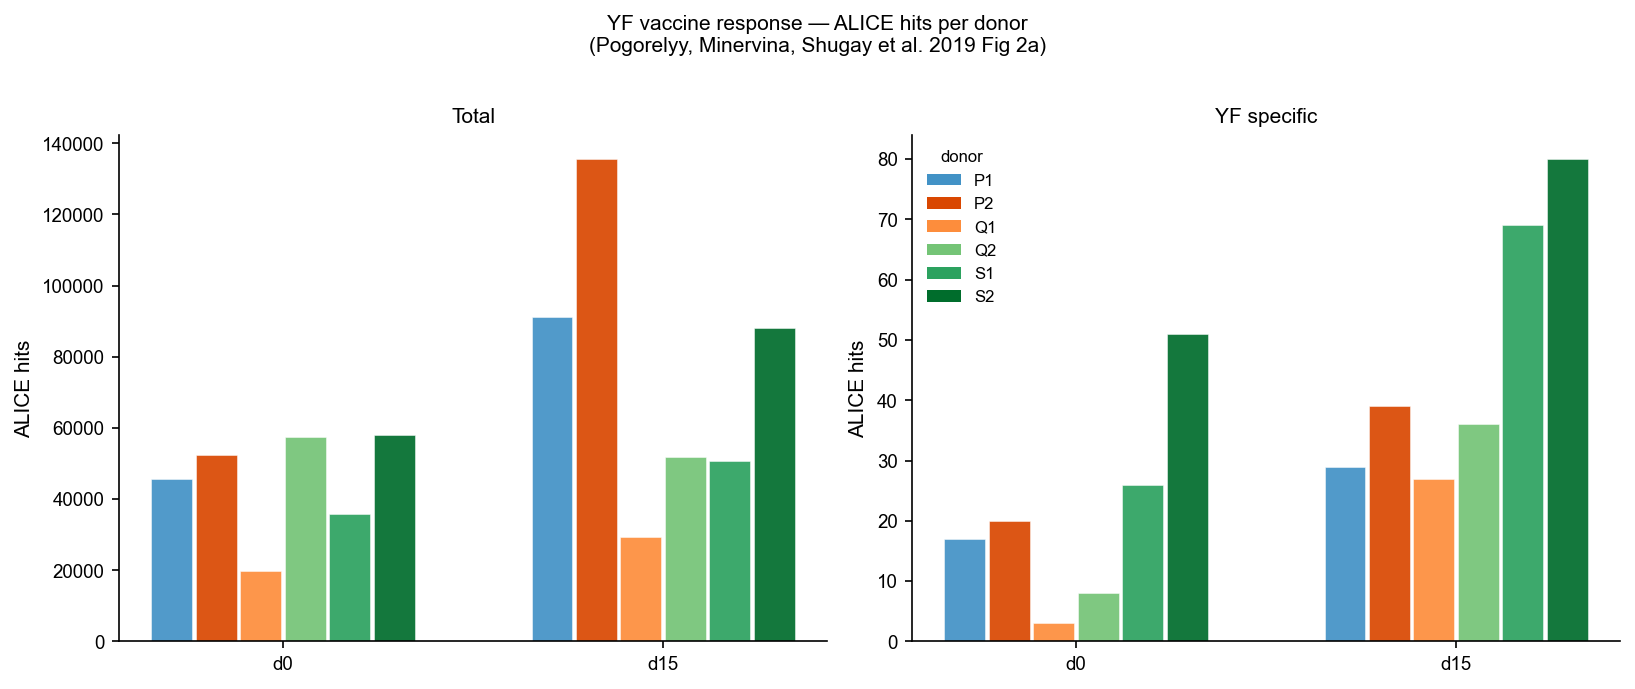

LLW hits: day15=280, day0=125
✓ Day-15 LLW hits > day-0 (expected for YFV response)


In [6]:
"""Cell 4: YF — ALICE hits per donor, Fig 2a style.

Left panel: total ALICE hits (count). Right panel: YF-specific (VDJdb LLWNGPMAV).
"""
import gzip as _gzip
import polars as _pl

# ── Load VDJdb LLWNGPMAV reference ────────────────────────────────────────────
with _gzip.open(VDJDB_PATH, "rt") as _fh:
    _vdb = _pl.read_csv(_fh, separator="\t", infer_schema_length=10000, ignore_errors=True)

llw_cdr3s: set[str] = set(
    _vdb.filter(
        (_pl.col("antigen.epitope") == "LLWNGPMAV") &
        (_pl.col("gene") == "TRB") &
        (_pl.col("species") == "HomoSapiens")
    ).select("cdr3").unique("cdr3")["cdr3"].to_list()
)
print(f"VDJdb LLWNGPMAV TRB reference: {len(llw_cdr3s)} unique CDR3s")

llw_rows = []
for (donor, day), tbl in sorted(yf_alice_tables.items()):
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)]
    n_llw = int(hits["junction_aa"].isin(llw_cdr3s).sum()) if not hits.empty else 0
    llw_rows.append({"Donor": donor, "Day": day, "LLW hits": n_llw})
df_llw = pd.DataFrame(llw_rows).sort_values(["Donor", "Day"]).reset_index(drop=True)

# ── Donor color palette (matches paper Fig 2a) ────────────────────────────────
YF_DONOR_COLORS = {
    "P1": "#4292c6",
    "P2": "#d94701",
    "Q1": "#fd8d3c",
    "Q2": "#74c476",
    "S1": "#2ca25f",
    "S2": "#006d2c",
}

donors_ordered = sorted(df_yf_summary["Donor"].unique())
days_ordered   = sorted(df_yf_summary["Day"].unique())
n_don = len(donors_ordered)
bw    = 0.11
gap   = 0.28

def _yf_barplot(ax, df_pivot_col, ylabel, title):
    for d_i, donor in enumerate(donors_ordered):
        for t_i, day in enumerate(days_ordered):
            row = df_pivot_col[(df_pivot_col["Donor"] == donor) & (df_pivot_col["Day"] == day)]
            val = float(row[df_pivot_col.columns[-1]].values[0]) if len(row) else 0.0
            x = t_i * (n_don * bw + gap) + d_i * bw
            ax.bar(x, val, bw * 0.92,
                   color=YF_DONOR_COLORS.get(donor, "#aaaaaa"),
                   label=donor if t_i == 0 else "_",
                   edgecolor="white", linewidth=0.25, alpha=0.92)
    tick_x = [t_i * (n_don * bw + gap) + (n_don - 1) * bw / 2 for t_i in range(len(days_ordered))]
    ax.set_xticks(tick_x)
    ax.set_xticklabels([f"d{d}" for d in days_ordered])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

df_total = df_yf_summary[["Donor", "Day", "ALICE clusters"]].copy()
df_yf_llw = df_llw.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
_yf_barplot(ax1, df_total, "ALICE hits", "Total")
_yf_barplot(ax2, df_yf_llw, "ALICE hits", "YF specific")

handles = [mpatches.Patch(facecolor=YF_DONOR_COLORS[d], edgecolor="none", label=d)
           for d in donors_ordered]
ax2.legend(handles=handles, title="donor", frameon=False, loc="upper left",
           fontsize=8, title_fontsize=8)

plt.suptitle("YF vaccine response — ALICE hits per donor\n(Pogorelyy, Minervina, Shugay et al. 2019 Fig 2a)",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

d15_total = df_llw[df_llw["Day"] == 15]["LLW hits"].sum()
d0_total  = df_llw[df_llw["Day"] == 0]["LLW hits"].sum()
print(f"LLW hits: day15={d15_total}, day0={d0_total}")
if d15_total > d0_total:
    print("✓ Day-15 LLW hits > day-0 (expected for YFV response)")
else:
    print("⚠ WARNING: day-15 LLW hits do NOT exceed day-0")


## VDJdb LLWNGPMAV overlap

ALICE hits are intersected with VDJdb 2025-12-29 TRB entries for LLWNGPMAV (all HLA-A\*02 entries). Exact CDR3 matching is used — the YFV-specific T cells in this dataset were sorted from the same donors, so exact identity is the appropriate criterion.
Donors carrying HLA-A\*02 are expected to show a stronger day-15 signal because this epitope is immunodominant in YFV-vaccinated A\*02 individuals (Pogorelyy, Minervina, Shugay et al. 2019).

In [7]:
"""Cell 5: VDJdb LLWNGPMAV table (computed in Cell 4)."""
display(
    df_llw.style
    .format({"LLW hits": "{:,}"})
    .background_gradient(subset=["LLW hits"], cmap="Blues")
    .set_caption("ALICE hits matching LLWNGPMAV (VDJdb 2025-12-29, TRB, exact match)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

yf_d15_llw = df_llw[df_llw["Day"] == 15]["LLW hits"].sum()
yf_d0_llw  = df_llw[df_llw["Day"] == 0]["LLW hits"].sum()
print(f"Day-15 LLW-matching ALICE hits: {yf_d15_llw}")
print(f"Day-0  LLW-matching ALICE hits: {yf_d0_llw}")


,Donor,Day,LLW hits
0,P1,0,17
1,P1,15,29
2,P2,0,20
3,P2,15,39
4,Q1,0,3
5,Q1,15,27
6,Q2,0,8
7,Q2,15,36
8,S1,0,26
9,S1,15,69


Day-15 LLW-matching ALICE hits: 280
Day-0  LLW-matching ALICE hits: 125


# Ankylosing Spondylitis (AS) Dataset

## Parse AS samples

Four donors from synovial fluid CD8+ TRB repertoires.
Donor B27 status metadata is hard-coded from study design.

In [8]:
"""Cell 6: Parse AS samples."""

AS_DONOR_META = {
    1: "B27_pos",
    2: "B27_pos",
    3: "B27_neg",
    4: "B27_pos",
}

as_samples: dict[int, LocusRepertoire] = {}

for donor_id, b27 in sorted(AS_DONOR_META.items()):
    pattern = f"Donor{donor_id}_B27_{b27}_SF_CD8.tsv.gz"
    fp = AS_DIR / pattern
    if not fp.exists():
        # Try globbing in case of slight filename variation.
        candidates = list(AS_DIR.glob(f"Donor{donor_id}_*.tsv.gz"))
        if not candidates:
            print(f"  WARNING: no file for Donor {donor_id} — skipping")
            continue
        fp = candidates[0]

    clonotypes = parser_yf.parse(str(fp))
    trb = [c for c in clonotypes if c.locus == "TRB"]
    rep = filter_functional(LocusRepertoire(clonotypes=trb, locus="TRB", repertoire_id=fp.stem))
    as_samples[donor_id] = rep
    print(f"  Donor {donor_id} ({b27}): {rep.clonotype_count:,} TRB clonotypes  [{fp.name}]")

print(f"\nLoaded {len(as_samples)} AS samples")

  Donor 1 (B27_pos): 29,193 TRB clonotypes  [Donor1_B27_pos_SF_CD8.tsv.gz]


  Donor 2 (B27_pos): 9,571 TRB clonotypes  [Donor2_B27_pos_SF_CD8.tsv.gz]


  Donor 3 (B27_neg): 38,404 TRB clonotypes  [Donor3_B27_neg_SF_CD8.tsv.gz]
  Donor 4 (B27_pos): 27,145 TRB clonotypes  [Donor4_B27_pos_SF_CD8.tsv.gz]

Loaded 4 AS samples


In [9]:
"""Cell 6b: Dataset size diagnostic after parsing AS."""
_all_as_count = sum(rep.clonotype_count for rep in as_samples.values())
_all_as_unique = len(set(
    c.junction_aa for rep in as_samples.values() for c in rep.clonotypes
))
print(f"AS: {_all_as_count:,} total clonotypes, {_all_as_unique:,} unique CDR3s across {len(as_samples)} samples")
print(f"  Pgen ({ALICE_PGEN_MODE!r}) computed only for sequences with n_neighbors >= {N_MIN_NEIGHBORS}.")
_check_ram("AS parsed")


AS: 104,313 total clonotypes, 100,453 unique CDR3s across 4 samples
  Pgen ('mc') computed only for sequences with n_neighbors >= 2.
  [AS parsed] RSS 16.48 GB


## Run ALICE on AS samples

Same parameters as YF (`match_mode="vj"`, `pgen_mode="1mm"`, BH-FDR < 0.001).
B27\+ donors (1, 2, 4) are expected to share convergent CDR3 neighbourhoods absent in the B27\- donor (3) — driven by shared HLA-B27-restricted antigen responses in synovial tissue.

Cluster analysis identifies hits shared across B27\+ donors as evidence for a public alloresponse.


In [10]:
"""Cell 7: Run ALICE on AS samples; collect cluster members."""

as_alice_hits: dict[int, pd.DataFrame] = {}
as_alice_tables: dict[int, pd.DataFrame] = {}
as_alice_rows = []

_t0_as = time.perf_counter()
print(f"AS ALICE start — pgen_mode={ALICE_PGEN_MODE!r}, n_jobs={N_JOBS}")
_check_ram("start")

for donor_id, rep in sorted(as_samples.items()):
    b27 = AS_DONOR_META[donor_id]
    _ts = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            min_neighbors=N_MIN_NEIGHBORS,
            mc_n_pool=MC_POOL_N,
            as_table=True,
            n_jobs=N_JOBS,
        )
    _te = time.perf_counter()

    tbl = result.table.to_pandas()
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()
    hits["donor_id"] = donor_id
    hits["b27"] = b27
    as_alice_hits[donor_id] = hits
    as_alice_tables[donor_id] = tbl
    as_alice_rows.append({
        "Donor": donor_id,
        "B27 status": b27,
        "Clonotypes": rep.clonotype_count,
        "ALICE clusters": len(hits),
        "Cluster %": 100 * len(hits) / max(1, rep.clonotype_count),
        "wall_s": round(_te - _ts, 1),
    })
    print(
        f"  Donor {donor_id} ({b27}): {rep.clonotype_count:,} clonotypes → {len(hits)} ALICE members"
        f"  [{_te - _ts:.1f}s, RSS {_rss_gb():.2f} GB]"
    )

_as_wall = time.perf_counter() - _t0_as
print(f"\nAS ALICE done: {_as_wall:.1f}s total | RSS {_rss_gb():.2f} GB")
_check_ram("end")

df_as_summary = pd.DataFrame(as_alice_rows)
display(
    df_as_summary.drop(columns=["wall_s"]).style
    .format({"Cluster %": "{:.1f}%", "Clonotypes": "{:,}", "ALICE clusters": "{:,}"})
    .background_gradient(subset=["Cluster %"], cmap="Blues")
    .set_caption(
        f"AS — ALICE cluster members per donor "
        f"(n_neighbors ≥ {N_MIN_NEIGHBORS}, BH-FDR < {FDR_THRESH})"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

df_as_all_hits = pd.concat(as_alice_hits.values(), ignore_index=True)
print(f"\nTotal AS ALICE cluster members: {len(df_as_all_hits)}")
print(f"Unique junction_aa: {df_as_all_hits['junction_aa'].nunique()}")
_peak_rss["as"] = _rss_gb()


AS ALICE start — pgen_mode='mc', n_jobs=8
  [start] RSS 16.48 GB


  Donor 1 (B27_pos): 29,193 clonotypes → 1094 ALICE members  [7.3s, RSS 16.48 GB]


  Donor 2 (B27_pos): 9,571 clonotypes → 458 ALICE members  [3.8s, RSS 16.48 GB]


  Donor 3 (B27_neg): 38,404 clonotypes → 1413 ALICE members  [7.7s, RSS 16.48 GB]


  Donor 4 (B27_pos): 27,145 clonotypes → 1469 ALICE members  [6.2s, RSS 16.48 GB]

AS ALICE done: 25.0s total | RSS 16.48 GB
  [end] RSS 16.48 GB


,Donor,B27 status,Clonotypes,ALICE clusters,Cluster %
0,1,B27_pos,"29,193","1,094",3.7%
1,2,B27_pos,"9,571",458,4.8%
2,3,B27_neg,"38,404","1,413",3.7%
3,4,B27_pos,"27,145","1,469",5.4%



Total AS ALICE cluster members: 4434
Unique junction_aa: 3450


In [11]:
"""Cell 7b: AS — cluster connectivity, joint B27+ analysis, and B27- exclusivity check.

Cluster algorithm: alice_hit_clusters() from mir.biomarkers.alice.
Uses V-gene-restricted 1mm CDR3 edges — only sequences sharing the same V-gene
family are connected, preventing spurious transitive merges across unrelated families.

Key result (Pogorelyy, Minervina, Shugay et al. 2019 Fig 2d): the motif CASSVGL[YF]STDTQYF (TRBV9 TRBJ2-3)
appears as the LARGEST connected component in pooled B27+ hits and is absent in B27-.
"""

# ── Per-donor: cluster hits into connected components (V-gene restricted) ─────
as_cluster_rows = []
as_hits_clustered: dict[int, pd.DataFrame] = {}

for donor_id, hits in sorted(as_alice_hits.items()):
    b27 = AS_DONOR_META[donor_id]
    clust = alice_hit_clusters(hits.copy()) if not hits.empty else hits
    as_hits_clustered[donor_id] = clust
    stats = cluster_stats(clust)
    as_cluster_rows.append({"Donor": donor_id, "B27": b27, **stats})

df_as_clusters = pd.DataFrame(as_cluster_rows).sort_values("Donor").reset_index(drop=True)
display(
    df_as_clusters.style
    .format({"median_size": "{:.1f}"})
    .background_gradient(subset=["n_clusters", "max_size", "n_multi"], cmap="Blues")
    .set_caption(
        f"AS — ALICE cluster connectivity per donor (FDR < {FDR_THRESH}, V-gene restricted)\n"
        "n_clusters = connected components | n_multi = clusters with ≥2 hits"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

# ── Joint B27+ cluster analysis ────────────────────────────────────────────────
# Pool all B27+ ALICE hits (deduplicated by junction_aa + v_call per donor) and
# cluster into connected components using V-gene-restricted 1mm edges.
# Expected: the CASSVGL[YF]STDTQYF (TRBV9 TRBJ2-3) motif is the largest cluster.
B27_POS_IDS = [d for d, status in AS_DONOR_META.items() if status == "B27_pos"]
B27_NEG_IDS = [d for d, status in AS_DONOR_META.items() if status == "B27_neg"]

# Deduplicate per donor before pooling to avoid inflated cluster sizes from
# multiple nucleotide sequences encoding the same amino acid.
b27_pos_hits_dedup = pd.concat(
    [
        as_alice_hits[d].drop_duplicates(subset=["junction_aa", "v_call"]).assign(donor_id=d)
        for d in B27_POS_IDS if d in as_alice_hits and not as_alice_hits[d].empty
    ],
    ignore_index=True,
)

MOTIF_CDR3S = {
    "CASSVGLYSTDTQYF", "CASSVGLFSTDTQYF", "CASSVGVYSTDTQYF",
    "CASSVATYSTDTQYF", "CASSLGLFSTDTQYF", "CASSAGLFSTDTQYF",
    "CASSPGLFSTDTQYF", "CASSVGGFGDTQYF",
}

print(f"\nJoint B27+ cluster analysis ({len(b27_pos_hits_dedup)} deduplicated hits from {len(B27_POS_IDS)} donors)")

b27_pos_clustered = alice_hit_clusters(b27_pos_hits_dedup.copy())
sizes = b27_pos_clustered.groupby("cluster_id").size().sort_values(ascending=False)
print(f"  {len(sizes)} clusters, top-5 sizes: {sizes.head(5).tolist()}")

# ── Motif cluster: should be rank 1 ──────────────────────────────────────────
motif_hits = b27_pos_clustered[b27_pos_clustered["junction_aa"].isin(MOTIF_CDR3S)]
if not motif_hits.empty:
    motif_cid = motif_hits.iloc[0]["cluster_id"]
    motif_cluster = b27_pos_clustered[b27_pos_clustered["cluster_id"] == motif_cid].copy()
    motif_size = len(motif_cluster)
    motif_rank = int((sizes > motif_size).sum()) + 1
    donors_in_cluster = sorted(motif_cluster["donor_id"].unique().tolist())
    print(f"  Motif cluster (CASSVGL[YF]STDTQYF, TRBV9): size={motif_size}, "
          f"rank={motif_rank}/{len(sizes)}, donors={donors_in_cluster}")

    motif_display = (
        motif_cluster[["donor_id", "junction_aa", "v_call", "j_call", "q_value"]]
        .drop_duplicates(subset=["junction_aa", "v_call"])
        .sort_values("q_value")
        .reset_index(drop=True)
        .rename(columns={"donor_id": "Donor", "junction_aa": "CDR3", "v_call": "V",
                          "j_call": "J", "q_value": "q-value"})
    )
    motif_display["motif"] = motif_display["CDR3"].isin(MOTIF_CDR3S).map(
        {True: "★ key", False: ""}
    )
    display(
        motif_display.style
        .format({"q-value": "{:.2e}"})
        .map(lambda v: "font-weight: bold; color: #c0392b" if v == "★ key" else "",
                  subset=["motif"])
        .background_gradient(subset=["q-value"], cmap="Blues_r")
        .set_caption(
            f"AS — joint B27+ motif cluster (rank {motif_rank}, size {motif_size})\n"
            "CASSVGL[YF]STDTQYF (TRBV9 TRBJ2-3) — AS-associated public TCR"
        )
        .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"),
                                                              ("font-size", "10pt")]}])
    )
else:
    print("  WARNING: motif sequences not found among B27+ ALICE hits")

# ── Largest non-motif cluster for comparison ─────────────────────────────────
print("\n  Largest cluster overall:")
lid = sizes.index[0]
lg = b27_pos_clustered[b27_pos_clustered["cluster_id"] == lid]
lg_donors = sorted(lg["donor_id"].unique().tolist())
print(f"  size={len(lg)}, donors={lg_donors}")
lg_dedup = lg.drop_duplicates(subset=["junction_aa","v_call"])
print(f"  Top-5 members (by q_value): " +
      ", ".join(f"{r['junction_aa']} ({r['v_call'].split('*')[0]})"
                for _, r in lg_dedup.sort_values("q_value").head(5).iterrows()))

# ── Convergent hits across B27+ donors ────────────────────────────────────────
b27_pos_tables_dedup = {
    str(d): as_alice_hits[d].drop_duplicates(subset=["junction_aa"])
    for d in B27_POS_IDS if d in as_alice_hits and not as_alice_hits[d].empty
}
as_b27pos_shared = find_shared_hits(b27_pos_tables_dedup, min_samples=2)
print(f"\nAS convergent hits in ≥2 B27+ donors: {len(as_b27pos_shared)}")
if not as_b27pos_shared.empty:
    display(
        as_b27pos_shared.head(20).style
        .background_gradient(subset=["n_samples"], cmap="Blues")
        .set_caption("AS — B27+ convergent ALICE hits (shared across ≥2 B27+ donors, exact CDR3)")
        .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"),
                                                              ("font-size", "10pt")]}])
    )

# ── B27- exclusivity check ────────────────────────────────────────────────────
b27_neg_cdr3s = {
    cdr3
    for d in B27_NEG_IDS
    for cdr3 in (as_alice_hits[d]["junction_aa"].unique() if d in as_alice_hits else [])
}
if not as_b27pos_shared.empty:
    n_b27pos_only = (~as_b27pos_shared["junction_aa"].isin(b27_neg_cdr3s)).sum()
    print(f"  Of those, {n_b27pos_only} are absent from B27- donor hits (B27-specific)")

motif_in_b27neg = any(cdr3 in b27_neg_cdr3s for cdr3 in MOTIF_CDR3S)
print(f"  Motif sequences in B27- ALICE hits: {motif_in_b27neg} (expected: False)")


,Donor,B27,n_hits,n_clusters,max_size,median_size,n_multi
0,1,B27_pos,1094,446,19,2.0,261
1,2,B27_pos,458,225,11,2.0,135
2,3,B27_neg,1413,524,39,2.0,297
3,4,B27_pos,1469,679,38,2.0,345



Joint B27+ cluster analysis (2389 deduplicated hits from 3 donors)
  1123 clusters, top-5 sizes: [41, 18, 17, 15, 14]
  Motif cluster (CASSVGL[YF]STDTQYF, TRBV9): size=41, rank=1/1123, donors=[1, 2, 4]


,Donor,CDR3,V,J,q-value,motif
0,4,CASSVGWYSTDTQYF,TRBV9*01,TRBJ2-3*01,3.03e-67,
1,4,CASSVGVYSTDTQYF,TRBV9*01,TRBJ2-3*01,3.77e-38,★ key
2,4,CASSVGWFSTDTQYF,TRBV9*01,TRBJ2-3*01,7.16e-38,
3,4,CASSPGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,2.50e-35,
4,4,CASSLGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,8.32e-32,
5,4,CASSVGRYSTDTQYF,TRBV9*01,TRBJ2-3*01,1.54e-30,
6,4,CASSGGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,1.96e-29,
7,4,CASSSGLYSTDTQYF,TRBV9*01,TRBJ2-3*01,1.96e-29,
8,4,CASSVGQYSTDTQYF,TRBV9*01,TRBJ2-3*01,2.38e-27,
9,4,CASSVALYSTDTQYF,TRBV9*01,TRBJ2-3*01,1.89e-24,



  Largest cluster overall:
  size=41, donors=[1, 2, 4]
  Top-5 members (by q_value): CASSVGWYSTDTQYF (TRBV9), CASSVGVYSTDTQYF (TRBV9), CASSVGWFSTDTQYF (TRBV9), CASSPGLYSTDTQYF (TRBV9), CASSLGLYSTDTQYF (TRBV9)

AS convergent hits in ≥2 B27+ donors: 22


,junction_aa,samples,n_samples
0,CASSVGLYSTDTQYF,"['1', '2', '4']",3
1,CASSAGLYSTDTQYF,"['1', '2', '4']",3
2,CASSLGLAGGPNTGELFF,"['1', '2', '4']",3
3,CASSVGLFSTDTQYF,"['1', '2', '4']",3
4,CASSYSMGSNTGELFF,"['1', '2']",2
5,CSVVAGGPYEQYF,"['1', '4']",2
6,CSARTGDTEAFF,"['1', '2']",2
7,CSARRGDTEAFF,"['1', '2']",2
8,CSAREVYEQYF,"['1', '4']",2
9,CATSDLGQGVGNEQFF,"['2', '4']",2


  Of those, 20 are absent from B27- donor hits (B27-specific)
  Motif sequences in B27- ALICE hits: False (expected: False)


## Build Hamming clonotype graph for AS ALICE hits

Each ALICE hit clonotype becomes a graph node. Edges connect pairs with Hamming distance ≤ 1 in the same V-gene.
We then build node color arrays for rendering with donor-specific colors.

In [12]:
"""Cell 8: Build Hamming distance graph for AS ALICE hits — all donors.

Build from all-donor deduplicated hits so Donor 3 (B27_neg) is visible
alongside B27+ donors. Matches Pogorelyy, Minervina, Shugay et al. 2019 Fig 2d.
"""

# ── Donor color palette ────────────────────────────────────────────────────────
DONOR_COLORS = {
    1: "#f6c915",   # gold/yellow — B27_pos (Donor 1)
    2: "#4292c6",   # blue        — B27_pos (Donor 2)
    3: "#41ab5d",   # green       — B27_neg (Donor 3)
    4: "#de77ae",   # pink/rose   — B27_pos (Donor 4)
}

# Highlight clonotypes of special interest (TRBV9 pair from literature).
HIGHLIGHT_CLONOTYPES = {
    ("TRBV9", "CASSVGLYSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSVGLFSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSVGVYSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSVATYSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSLGLFSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSAGLFSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSPGLFSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSVGGFGDTQYF",  "TRBJ2-3"),
}

def _as_clonotype(row: pd.Series) -> Clonotype:
    return Clonotype(
        junction_aa=row.get("junction_aa") or "",
        v_call=row.get("v_call") or "",
        j_call=row.get("j_call") or "",
        duplicate_count=1,
        locus="TRB",
    )

# Include ALL 4 donors (not just B27+) so Donor 3 (B27_neg) appears in the graph.
all_hits_dedup = pd.concat(
    [
        as_alice_hits[d].drop_duplicates(subset=["junction_aa", "v_call"]).assign(donor_id=d)
        for d in sorted(as_alice_hits)
        if not as_alice_hits[d].empty
    ],
    ignore_index=True,
)

clonotype_list = []
clonotype_donor_ids = []
for _, row in all_hits_dedup.iterrows():
    clonotype_list.append(_as_clonotype(row))
    clonotype_donor_ids.append(int(row["donor_id"]))

print(f"Graph input: {len(clonotype_list)} nodes ({len(as_alice_hits)} donors, all B27+/B27-)")
print(f"ALICE hit counts: {', '.join(f'Donor {d}: {len(as_alice_hits[d])}' for d in sorted(as_alice_hits))}")

g = build_edit_distance_graph(
    clonotype_list,
    metric="hamming",
    threshold=1,
    v_call_match=True,
    n_jobs=N_JOBS,
)
g.vs["donor_id"] = clonotype_donor_ids

print(f"Graph: {g.vcount()} nodes, {g.ecount()} edges")


Graph input: 3506 nodes (4 donors, all B27+/B27-)
ALICE hit counts: Donor 1: 1094, Donor 2: 458, Donor 3: 1413, Donor 4: 1469


Graph: 3506 nodes, 3142 edges


## Render AS graph with donor colors and highlighted targets

Rendering strategy:
- Compute Fruchterman-Reingold layout
- Draw edges (thin grey lines)
- Single-donor nodes: filled circle with donor color
- Multi-donor nodes: pie-chart wedges per donor
- Star markers on target clonotypes

Components: 991, sizes top-5: [41, 28, 27, 27, 20]
Highlighted nodes in graph: 7/8
  Motif cluster: rank=1/991, size=41, donors=[1, 2, 4]
  Highlighted in motif: 14
  ✓ Motif IS rank-1 (Pogorelyy, Minervina, Shugay et al. 2019 Fig 2d)


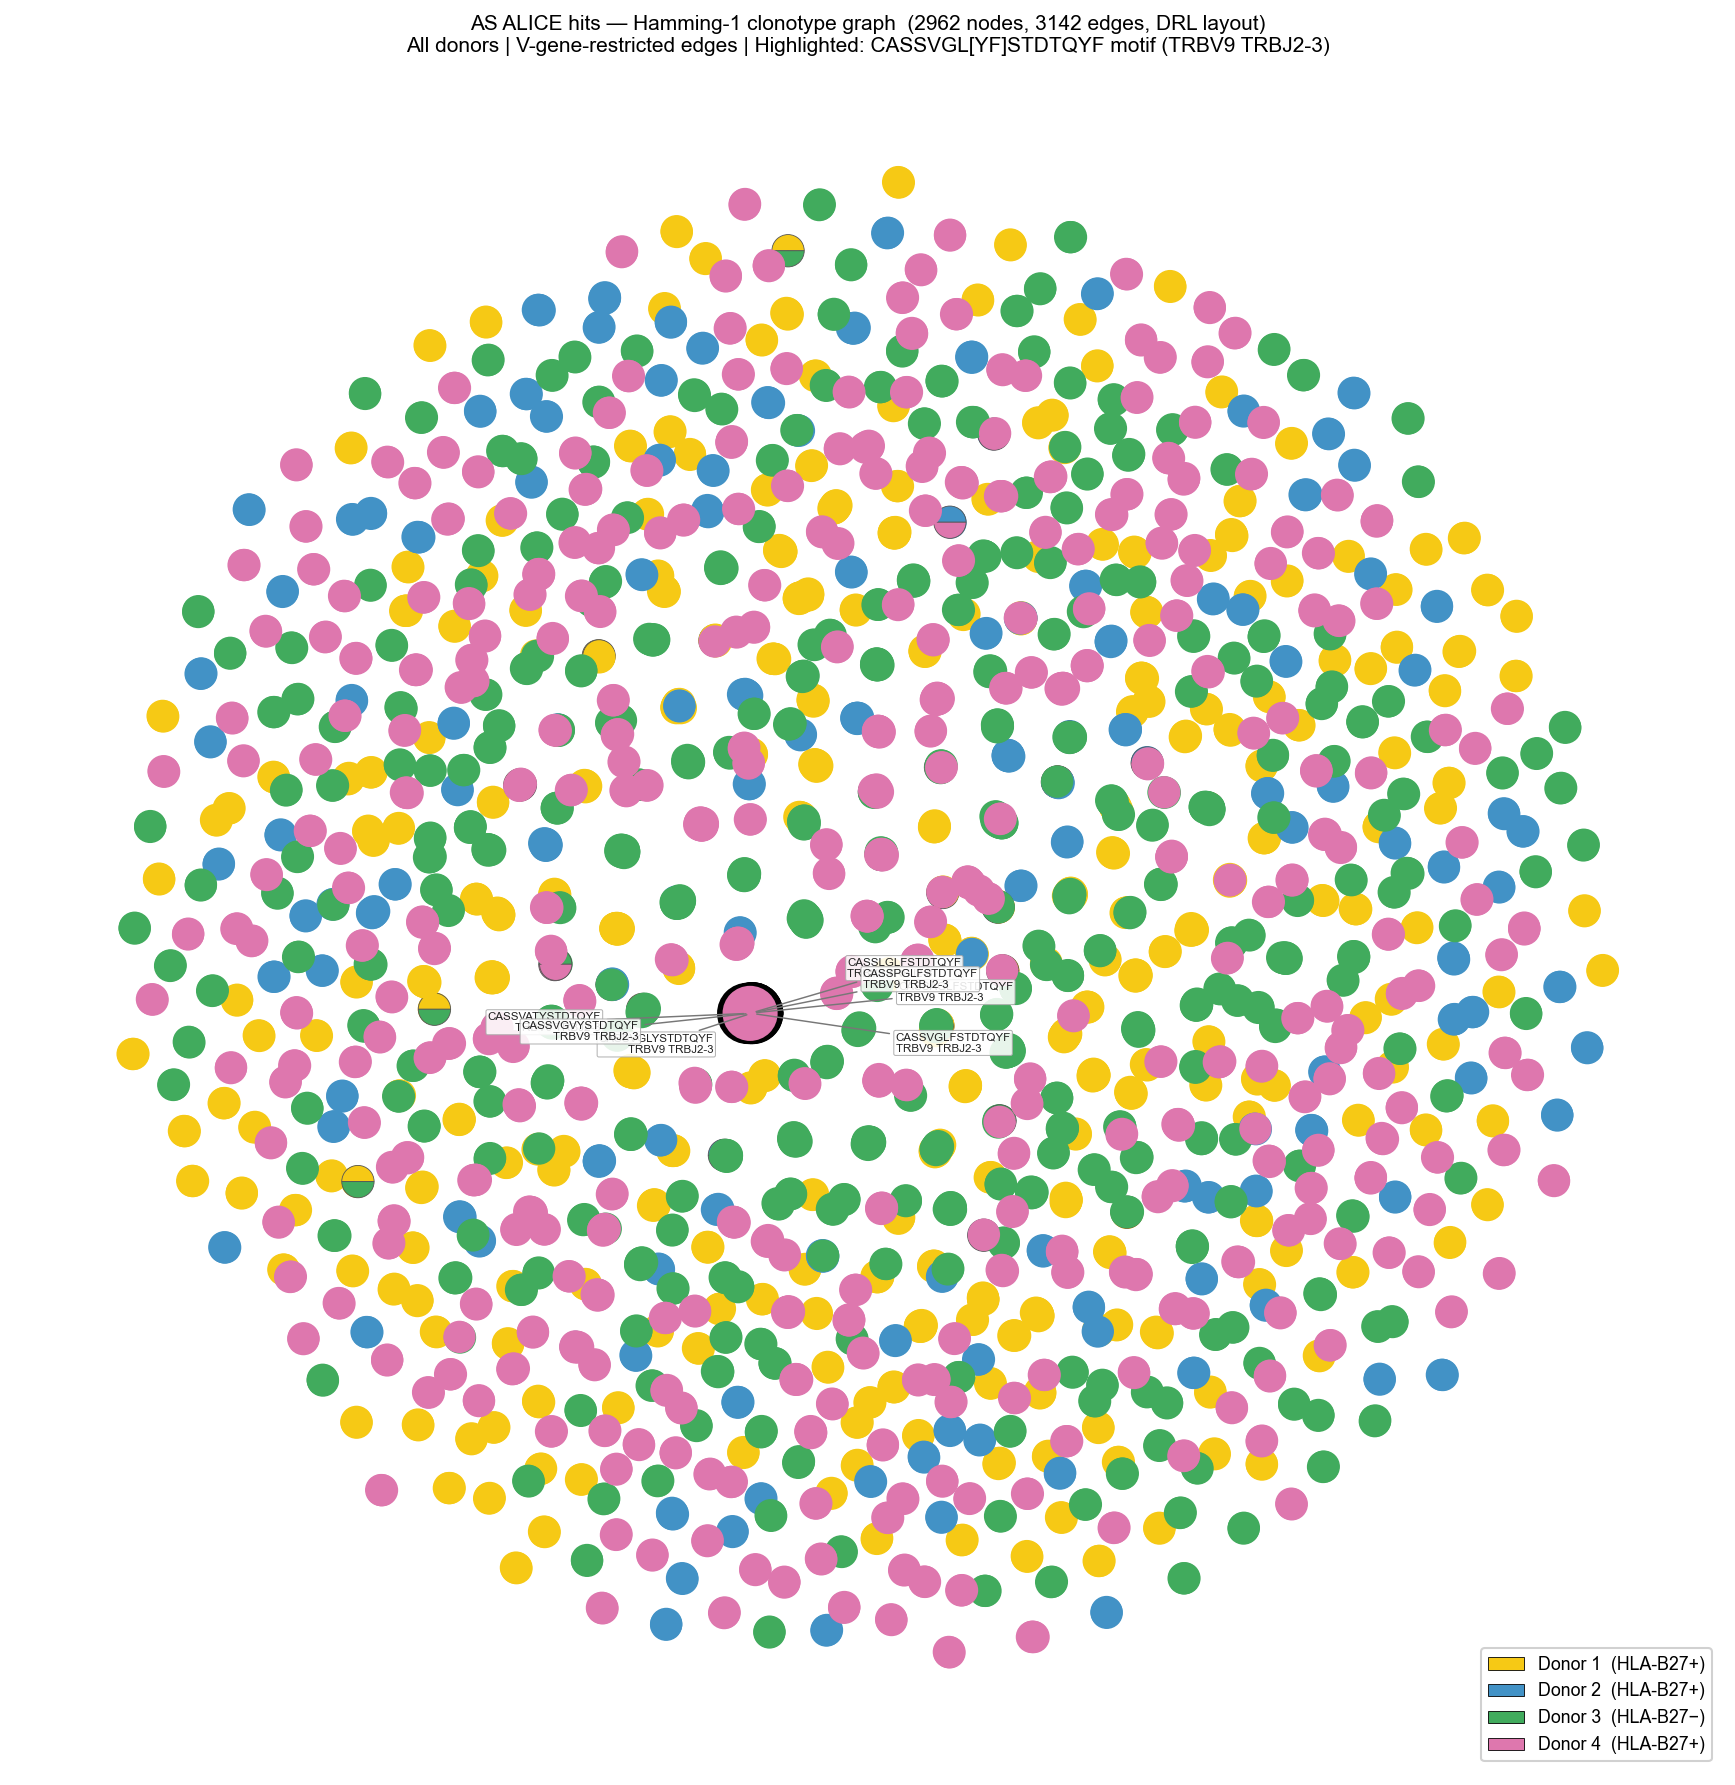

In [13]:
"""Cell 9: Render AS Hamming graph — all donors, DRL layout, pie-chart shared nodes.

Matches Pogorelyy, Minervina, Shugay et al. 2019 Fig 2d.
Donor 3 (B27_neg) is shown in green; pie-chart nodes for sequences shared across donors.
"""
from matplotlib.patches import Circle, Wedge

# ── Subgraph: keep only connected components with ≥ 2 nodes ──────────────────
comp_sizes = g.connected_components().sizes()
subg = g
if max(comp_sizes) > 1:
    large_comps = [i for i, sz in enumerate(comp_sizes) if sz >= 2]
    keep = [v for v in range(g.vcount())
            if g.connected_components().membership[v] in large_comps]
    if keep:
        subg = g.induced_subgraph(keep)

if subg.vcount() == 0:
    print("No connected components with ≥ 2 nodes.")
else:
    # DRL layout — Distributed Recursive Layout; separated clusters, cytoscape-like
    np.random.seed(SEED)
    layout = subg.layout("drl", seed=None)
    coords = np.array(layout.coords)
    mn, mx = coords.min(axis=0), coords.max(axis=0)
    coords = (coords - mn) / np.where(mx - mn > 0, mx - mn, 1.0)

    NODE_RADIUS      = 0.011
    HIGHLIGHT_RADIUS = NODE_RADIUS * 1.8

    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, 1.08)

    # Edges
    for e in subg.es:
        s, t = e.source, e.target
        ax.plot([coords[s, 0], coords[t, 0]], [coords[s, 1], coords[t, 1]],
                color="#cccccc", linewidth=0.4, zorder=1)

    j_call_in_graph = "j_call" in subg.vs.attributes()

    # Group vertices by (CDR3, v_call) → merge same-sequence across donors for pie chart
    key_to_nodes: dict[tuple, list[int]] = defaultdict(list)
    for v in range(subg.vcount()):
        key_to_nodes[(subg.vs[v]["name"], subg.vs[v]["v_call"])].append(v)

    highlight_positions: list[tuple[float, float, str]] = []

    for key, node_ids in key_to_nodes.items():
        donors_here = sorted({subg.vs[v]["donor_id"] for v in node_ids})
        pos = coords[node_ids, :].mean(axis=0)
        cx, cy = float(pos[0]), float(pos[1])

        jaa   = key[0]
        vgene = key[1]
        jgene = ""
        if j_call_in_graph:
            raw = subg.vs[node_ids[0]]["j_call"]
            jgene = raw if raw is not None else ""

        vg_stripped = vgene.split("*")[0]
        jg_stripped = jgene.split("*")[0] if jgene else ""
        is_highlight = (vg_stripped, jaa, jg_stripped) in HIGHLIGHT_CLONOTYPES
        radius = HIGHLIGHT_RADIUS if is_highlight else NODE_RADIUS

        if len(donors_here) == 1:
            # Single donor — solid circle
            ax.add_patch(Circle(
                (cx, cy), radius,
                facecolor=DONOR_COLORS.get(donors_here[0], "#cccccc"),
                edgecolor="black" if is_highlight else "none",
                linewidth=1.5 if is_highlight else 0, zorder=3))
        else:
            # Multiple donors — pie chart of donor colours
            angle_per = 360.0 / len(donors_here)
            for k, did in enumerate(donors_here):
                ax.add_patch(Wedge(
                    (cx, cy), radius, k * angle_per, (k + 1) * angle_per,
                    facecolor=DONOR_COLORS.get(did, "#cccccc"),
                    edgecolor="black" if is_highlight else "#555555",
                    linewidth=1.5 if is_highlight else 0.4, zorder=3))

        if is_highlight:
            highlight_positions.append((cx, cy, jaa))

    # Labels on highlighted (motif) nodes
    if highlight_positions:
        cx_c = float(np.mean([p[0] for p in highlight_positions]))
        cy_c = float(np.mean([p[1] for p in highlight_positions]))
        for cx, cy, label in highlight_positions:
            dx, dy = cx - cx_c, cy - cy_c
            norm_d = max(float(np.sqrt(dx**2 + dy**2)), 0.001)
            dx, dy = dx / norm_d, dy / norm_d
            offset = 0.10
            tx = float(np.clip(cx + dx * offset, 0.03, 0.97))
            ty = float(np.clip(cy + dy * offset, 0.03, 0.97))
            ha = "left" if dx >= 0 else "right"
            ax.annotate(
                f"{label}\nTRBV9 TRBJ2-3",
                xy=(cx, cy), xytext=(tx, ty),
                fontsize=5.5, ha=ha, va="center", zorder=7, color="#222222",
                arrowprops=dict(arrowstyle="-", color="#777777", lw=0.7),
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                          alpha=0.88, edgecolor="#aaaaaa", linewidth=0.5))

    # Legend
    legend_handles = []
    for did in sorted(DONOR_COLORS):
        b27 = AS_DONOR_META[did]
        hla = "HLA-B27+" if b27 == "B27_pos" else "HLA-B27−"
        legend_handles.append(mpatches.Patch(
            facecolor=DONOR_COLORS[did], edgecolor="black", linewidth=0.4,
            label=f"Donor {did}  ({hla})"))
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8.5,
              frameon=True, framealpha=0.9, edgecolor="#cccccc")

    ax.set_title(
        f"AS ALICE hits — Hamming-1 clonotype graph  "
        f"({subg.vcount()} nodes, {subg.ecount()} edges, DRL layout)\n"
        f"All donors | V-gene-restricted edges | "
        f"Highlighted: CASSVGL[YF]STDTQYF motif (TRBV9 TRBJ2-3)",
        fontsize=10)
    plt.tight_layout()

    # ── Consistency check ─────────────────────────────────────────────────────
    comps = subg.connected_components()
    j_call_in_subg = "j_call" in subg.vs.attributes()
    sizes = sorted([(len(comps[ci]), ci) for ci in range(len(comps))], reverse=True)
    largest_sz, largest_idx = sizes[0]
    print(f"Components: {len(comps)}, sizes top-5: {[s for s, _ in sizes[:5]]}")
    print(f"Highlighted nodes in graph: {len(highlight_positions)}/{len(HIGHLIGHT_CLONOTYPES)}")

    motif_comp_idx = None
    for ci in range(len(comps)):
        for v in comps[ci]:
            vg  = (subg.vs[v]["v_call"] or "").split("*")[0]
            jaa = subg.vs[v]["name"] or ""
            _jg = (subg.vs[v]["j_call"] or "") if j_call_in_subg else ""
            jg  = _jg.split("*")[0] if _jg else ""
            if (vg, jaa, jg) in HIGHLIGHT_CLONOTYPES:
                motif_comp_idx = ci
                break
        if motif_comp_idx is not None:
            break

    if motif_comp_idx is not None:
        motif_nodes  = list(comps[motif_comp_idx])
        motif_rank   = next(i+1 for i,(_, ci) in enumerate(sizes) if ci == motif_comp_idx)
        motif_donors = sorted({subg.vs[v]["donor_id"] for v in motif_nodes})
        n_hl = sum(
            1 for v in motif_nodes
            if ((subg.vs[v]["v_call"] or "").split("*")[0],
                subg.vs[v]["name"] or "",
                ((subg.vs[v]["j_call"] or "").split("*")[0]
                 if j_call_in_subg else "")) in HIGHLIGHT_CLONOTYPES)
        print(f"  Motif cluster: rank={motif_rank}/{len(comps)}, size={len(motif_nodes)}, donors={motif_donors}")
        print(f"  Highlighted in motif: {n_hl}")
        if motif_rank == 1:
            print("  ✓ Motif IS rank-1 (Pogorelyy, Minervina, Shugay et al. 2019 Fig 2d)")
        else:
            print(f"  ⚠ Motif rank={motif_rank}")
    else:
        print("  ⚠ No highlight sequences found in graph")

    plt.show()


# Mixed Lymphocyte Reaction (MLR) Dataset

## Load Adaptive files and build TRB repertoires

The parser maps the Adaptive columns to AIRR-style fields. Files are parsed into single-locus TRB repertoires.
Gene names are normalized (e.g. `TCRBV01` → `TRBV1`).

In [14]:
"""Cell 10: Parse MLR samples from Adaptive immunoSEQ files."""
parser_adaptive = AdaptiveParser(locus="TRB")

def parse_mlr_filename(path: Path) -> dict[str, object]:
    """Return sample metadata encoded in the MLR filename."""
    stem = path.name.removesuffix(".tsv.gz").removesuffix(".tsv")
    parts = stem.split("_")
    if "Fresh" in parts:
        condition = "fresh"
        idx = parts.index("Fresh")
    elif "Proliferating" in parts:
        condition = "proliferating"
        idx = parts.index("Proliferating")
    else:
        raise ValueError(f"Could not infer condition from {path.name}")
    return {
        "sample_id": stem,
        "sample_group": "_".join(parts[:idx]),
        "condition": condition,
        "replicate": int(parts[-1]),
    }

mlr_files = sorted(fp for fp in MLR_DIR.glob("*.tsv.gz") if "Stimulator" not in fp.name)
print(f"Found {len(mlr_files)} MLR files")

mlr_samples: dict[str, LocusRepertoire] = {}
mlr_rows: list[dict[str, object]] = []

for fp in mlr_files:
    meta = parse_mlr_filename(fp)
    rep = parser_adaptive.parse_file(fp, sample_id=str(meta["sample_id"]), locus="TRB")
    rep_functional = rep.subsample_functional()
    if meta["condition"] == "fresh" and rep_functional.clonotype_count > MLR_FRESH_CAP:
        _sampled = random.sample(rep_functional.clonotypes, MLR_FRESH_CAP)
        rep_functional = LocusRepertoire(
            clonotypes=_sampled, locus="TRB",
            repertoire_id=rep_functional.repertoire_id,
        )
    rep_functional.repertoire_metadata.update(meta)
    mlr_samples[str(meta["sample_id"])] = rep_functional
    mlr_rows.append({
        **meta,
        "n_clonotypes_total": rep.clonotype_count,
        "n_clonotypes": rep_functional.clonotype_count,
        "n_duplicates_total": rep.duplicate_count,
        "n_duplicates": rep_functional.duplicate_count,
    })
    print(f"  {fp.name}: {rep.clonotype_count:,} total → {rep_functional.clonotype_count:,} functional")

df_mlr_samples = pd.DataFrame(mlr_rows).sort_values(["sample_group", "condition", "replicate"]).reset_index(drop=True)
display(
    df_mlr_samples.style
    .format({"n_clonotypes_total": "{:,}", "n_clonotypes": "{:,}",
             "n_duplicates_total": "{:,}", "n_duplicates": "{:,}"})
    .set_caption("MLR samples — loaded functional clonotypes")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)


Found 24 MLR files


  MLR7_TCR1_Fresh_1.tsv.gz: 562,409 total → 300,000 functional


  MLR7_TCR1_Fresh_2.tsv.gz: 448,953 total → 300,000 functional


  MLR7_TCR1_Proliferating_1.tsv.gz: 45,698 total → 40,301 functional


  MLR7_TCR1_Proliferating_2.tsv.gz: 45,971 total → 40,405 functional


...

  TCR6_Fresh_Responder_R_1.tsv.gz: 654,314 total → 300,000 functional


  TCR6_Fresh_Responder_R_2.tsv.gz: 721,281 total → 300,000 functional


  TCR6_Proliferating_1.tsv.gz: 80,243 total → 73,229 functional


  TCR6_Proliferating_2.tsv.gz: 84,066 total → 76,699 functional


,sample_id,sample_group,condition,replicate,n_clonotypes_total,n_clonotypes,n_duplicates_total,n_duplicates
0,MLR7_TCR1_Fresh_1,MLR7_TCR1,fresh,1,"562,409","300,000","39,060,366","22,342,313"
1,MLR7_TCR1_Fresh_2,MLR7_TCR1,fresh,2,"448,953","300,000","14,774,134","10,201,749"
2,MLR7_TCR1_Proliferating_1,MLR7_TCR1,proliferating,1,"45,698","40,301","28,247,803","26,145,533"
3,MLR7_TCR1_Proliferating_2,MLR7_TCR1,proliferating,2,"45,971","40,405","31,989,495","29,412,778"
4,MLR8_TCR2_Fresh_1,MLR8_TCR2,fresh,1,"848,893","300,000","21,189,395","7,075,768"
5,MLR8_TCR2_Fresh_2,MLR8_TCR2,fresh,2,"945,294","300,000","32,165,682","10,517,176"
6,MLR8_TCR2_Proliferating_1,MLR8_TCR2,proliferating,1,"104,389","93,251","31,406,916","27,112,376"
7,MLR8_TCR2_Proliferating_2,MLR8_TCR2,proliferating,2,"88,868","79,518","17,719,903","15,213,872"
8,MLR9_TCR3_Fresh_1,MLR9_TCR3,fresh,1,"706,881","300,000","20,815,699","8,799,036"
9,MLR9_TCR3_Fresh_2,MLR9_TCR3,fresh,2,"578,431","300,000","17,854,323","8,890,743"


In [15]:
"""Cell 10b: Dataset size diagnostic after parsing MLR."""
_all_mlr_count = sum(rep.clonotype_count for rep in mlr_samples.values())
_all_mlr_unique = len(set(
    c.junction_aa for rep in mlr_samples.values() for c in rep.clonotypes
))
print(f"MLR: {_all_mlr_count:,} total clonotypes, {_all_mlr_unique:,} unique CDR3s across {len(mlr_samples)} samples")
print(f"  Fresh samples capped at {MLR_FRESH_CAP:,} clonotypes.")
print(f"  Pgen ({ALICE_PGEN_MODE!r}) computed only for sequences with n_neighbors >= {N_MIN_NEIGHBORS}.")
_check_ram("MLR parsed")


MLR: 4,182,737 total clonotypes, 2,942,494 unique CDR3s across 24 samples
  Fresh samples capped at 300,000 clonotypes.
  Pgen ('mc') computed only for sequences with n_neighbors >= 2.
  [MLR parsed] RSS 18.91 GB


## Run ALICE on all MLR samples

ALICE is run with `match_mode="vj"` conditioned on both V and J gene usage.
The primary metric is **cluster member fraction**: the proportion of CDR3s with at least one Hamming-1 neighbour in the same repertoire that passes BH-FDR.

Hypothesis: **proliferating > fresh** — antigen-driven alloresponse produces convergent CDR3 clusters absent in naive/unstimulated repertoires.

In [16]:
"""Cell 11: Run ALICE on all MLR samples; collect cluster member fractions."""

mlr_alice_tables: dict[str, pd.DataFrame] = {}
mlr_alice_rows = []

_t0_mlr = time.perf_counter()
print(f"MLR ALICE start — {len(mlr_samples)} samples, pgen_mode={ALICE_PGEN_MODE!r}, n_jobs={N_JOBS}")
_check_ram("start")

for sample_id, rep in sorted(mlr_samples.items()):
    meta = rep.repertoire_metadata
    _ts = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            min_neighbors=N_MIN_NEIGHBORS,
            mc_n_pool=MC_POOL_N,
            as_table=True,
            n_jobs=N_JOBS,
        )
    _te = time.perf_counter()

    tbl = result.table.to_pandas()
    mlr_alice_tables[sample_id] = tbl
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()

    mlr_alice_rows.append({
        "sample_id": sample_id,
        "sample_group": meta.get("sample_group", ""),
        "condition": meta.get("condition", ""),
        "replicate": meta.get("replicate", ""),
        "n_clonotypes": rep.clonotype_count,
        "n_cluster_members": len(hits),
        "cluster_fraction": len(hits) / max(1, rep.clonotype_count),
        "wall_s": round(_te - _ts, 1),
    })
    print(
        f"  {sample_id}: {rep.clonotype_count:,} clonotypes → "
        f"{len(hits)} ALICE members ({100*len(hits)/rep.clonotype_count:.1f}%)"
        f"  [{_te - _ts:.1f}s, RSS {_rss_gb():.2f} GB]"
    )

_mlr_wall = time.perf_counter() - _t0_mlr
print(f"\nMLR ALICE done: {_mlr_wall:.1f}s total | RSS {_rss_gb():.2f} GB")
_check_ram("end")

df_mlr_alice = pd.DataFrame(mlr_alice_rows).sort_values(
    ["condition", "sample_group", "replicate"]
).reset_index(drop=True)

df_cond_summary = (
    df_mlr_alice.groupby("condition")["cluster_fraction"]
    .agg(["mean", "std", "min", "max", "count"])
    .rename(columns={"mean": "Mean", "std": "SD", "min": "Min", "max": "Max", "count": "N"})
    .reset_index()
)
display(
    df_cond_summary.style
    .format({"Mean": "{:.4f}", "SD": "{:.4f}", "Min": "{:.4f}", "Max": "{:.4f}"})
    .background_gradient(subset=["Mean"], cmap="Blues")
    .set_caption(f"MLR — cluster fraction by condition (n_neighbors ≥ {N_MIN_NEIGHBORS}, BH-FDR < {FDR_THRESH})")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

_fresh_mean = df_mlr_alice[df_mlr_alice["condition"] == "fresh"]["cluster_fraction"].mean()
_prolif_mean = df_mlr_alice[df_mlr_alice["condition"] == "proliferating"]["cluster_fraction"].mean()
_direction_ok = _prolif_mean > _fresh_mean
print(f"\nConsistency check: proliferating mean ({_prolif_mean:.4f}) > fresh mean ({_fresh_mean:.4f}): {_direction_ok}")
if not _direction_ok:
    print("  WARNING: expected proliferating > fresh — check pgen_mode and FDR threshold")
_peak_rss["mlr"] = _rss_gb()


MLR ALICE start — 24 samples, pgen_mode='mc', n_jobs=8
  [start] RSS 18.91 GB


  MLR7_TCR1_Fresh_1: 300,000 clonotypes → 39097 ALICE members (13.0%)  [20.6s, RSS 18.91 GB]


  MLR7_TCR1_Fresh_2: 300,000 clonotypes → 40928 ALICE members (13.6%)  [20.5s, RSS 18.91 GB]


  MLR7_TCR1_Proliferating_1: 40,301 clonotypes → 7214 ALICE members (17.9%)  [8.0s, RSS 18.91 GB]


  MLR7_TCR1_Proliferating_2: 40,405 clonotypes → 7845 ALICE members (19.4%)  [8.1s, RSS 18.91 GB]


...

  TCR6_Fresh_Responder_R_2: 300,000 clonotypes → 33645 ALICE members (11.2%)  [16.5s, RSS 18.91 GB]


  TCR6_Proliferating_1: 73,229 clonotypes → 14096 ALICE members (19.2%)  [11.0s, RSS 18.91 GB]


  TCR6_Proliferating_2: 76,699 clonotypes → 14730 ALICE members (19.2%)  [11.1s, RSS 18.91 GB]

MLR ALICE done: 332.9s total | RSS 18.91 GB
  [end] RSS 18.91 GB


,condition,Mean,SD,Min,Max,N
0,fresh,0.1232,0.0095,0.1121,0.1367,12
1,proliferating,0.1785,0.0297,0.1242,0.2448,12



Consistency check: proliferating mean (0.1785) > fresh mean (0.1232): True


In [17]:
"""Cell 11b: MLR — cluster connectivity and allogeneic convergent-hit analysis."""

# ── Per-sample: cluster hits into connected components ────────────────────────
mlr_cluster_rows = []
mlr_hits_clustered: dict[str, pd.DataFrame] = {}

for sample_id, tbl in sorted(mlr_alice_tables.items()):
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()
    meta = mlr_samples[sample_id].repertoire_metadata
    cond = meta.get("condition", "")
    clust = alice_hit_clusters(hits) if not hits.empty else hits
    mlr_hits_clustered[sample_id] = clust
    stats = cluster_stats(clust)
    mlr_cluster_rows.append({"sample_id": sample_id, "condition": cond, **stats})

df_mlr_clusters = (
    pd.DataFrame(mlr_cluster_rows)
    .sort_values(["condition", "sample_id"])
    .reset_index(drop=True)
)
display(
    df_mlr_clusters.style
    .format({"median_size": "{:.1f}"})
    .background_gradient(subset=["n_clusters", "max_size", "n_multi"], cmap="Blues")
    .set_caption(
        f"MLR — ALICE cluster connectivity per sample (FDR < {FDR_THRESH})\n"
        "n_clusters = connected components | n_multi = clusters with ≥2 hits"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

# ── Convergent hits in proliferating samples (shared across ≥2 samples) ───────
prolif_tables = {
    sid: t for sid, t in mlr_hits_clustered.items()
    if mlr_samples[sid].repertoire_metadata.get("condition") == "proliferating"
    and not t.empty
}
mlr_prolif_shared = find_shared_hits(prolif_tables, min_samples=2)
print(f"\nMLR allogeneic convergent hits (≥2 proliferating samples): {len(mlr_prolif_shared)}")
if not mlr_prolif_shared.empty:
    display(
        mlr_prolif_shared.head(20).style
        .background_gradient(subset=["n_samples"], cmap="Blues")
        .set_caption("MLR — convergent ALICE hits in proliferating samples (≥2 samples)")
        .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
    )

# ── Condition-level cluster summary ───────────────────────────────────────────
df_cond_clusters = (
    df_mlr_clusters.groupby("condition")[["n_clusters", "max_size", "n_multi"]]
    .agg(["mean", "std"])
    .round(1)
)
print("\nCluster connectivity by condition:")
print(df_cond_clusters.to_string())


,sample_id,condition,n_hits,n_clusters,max_size,median_size,n_multi
0,MLR7_TCR1_Fresh_1,fresh,39097,15313,234,2.0,8874
1,MLR7_TCR1_Fresh_2,fresh,40928,15256,359,2.0,8884
2,MLR8_TCR2_Fresh_1,fresh,34743,11245,261,2.0,7523
3,MLR8_TCR2_Fresh_2,fresh,34856,11301,280,2.0,7528
4,MLR9_TCR3_Fresh_1,fresh,34157,12900,165,2.0,7759
5,MLR9_TCR3_Fresh_2,fresh,35087,13826,255,2.0,8137
6,TCR4_Fresh_Responder_R_1,fresh,22271,11496,234,1.0,5212
7,TCR4_Fresh_Responder_R_2,fresh,30358,14090,207,1.0,7025
8,TCR5_Fresh_Responder_R_1,fresh,36508,11520,332,2.0,7649
9,TCR5_Fresh_Responder_R_2,fresh,38212,13224,289,2.0,8098



MLR allogeneic convergent hits (≥2 proliferating samples): 13978


,junction_aa,samples,n_samples
0,CASSPQETQYF,"['MLR7_TCR1_Proliferating_1', 'MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",12
1,CASSLQETQYF,"['MLR7_TCR1_Proliferating_1', 'MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",12
2,CASSLGGNQPQHF,"['MLR7_TCR1_Proliferating_1', 'MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",11
3,CASSPGETQYF,"['MLR7_TCR1_Proliferating_1', 'MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",11
4,CASSLGETQYF,"['MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",11
5,CASSPSSYEQYF,"['MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",10
6,CASSQAETQYF,"['MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",10
7,CASSVGGNTEAFF,"['MLR7_TCR1_Proliferating_1', 'MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'TCR4_Proliferating_1', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",10
8,CASSLQGYGYTF,"['MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR4_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",9
9,CASSLGYEQYF,"['MLR7_TCR1_Proliferating_2', 'MLR8_TCR2_Proliferating_1', 'MLR8_TCR2_Proliferating_2', 'MLR9_TCR3_Proliferating_1', 'MLR9_TCR3_Proliferating_2', 'TCR5_Proliferating_1', 'TCR5_Proliferating_2', 'TCR6_Proliferating_1', 'TCR6_Proliferating_2']",9



Cluster connectivity by condition:
              n_clusters         max_size       n_multi       
                    mean     std     mean   std    mean    std
condition                                                     
fresh            12748.9  1576.4    271.9  64.1  7636.2  950.5
proliferating     6117.3  1293.0    146.5  48.5  2311.8  532.2


## Fresh vs Proliferating: ALICE cluster fraction

Boxplot with individual sample overlay comparing **cluster member fraction** between fresh and proliferating conditions.
A one-sided Mann-Whitney U test assesses whether proliferating samples have significantly higher cluster fractions (greater convergent CDR3 usage).

Mann-Whitney U (proliferating > fresh): p = 6.167e-05  (***)


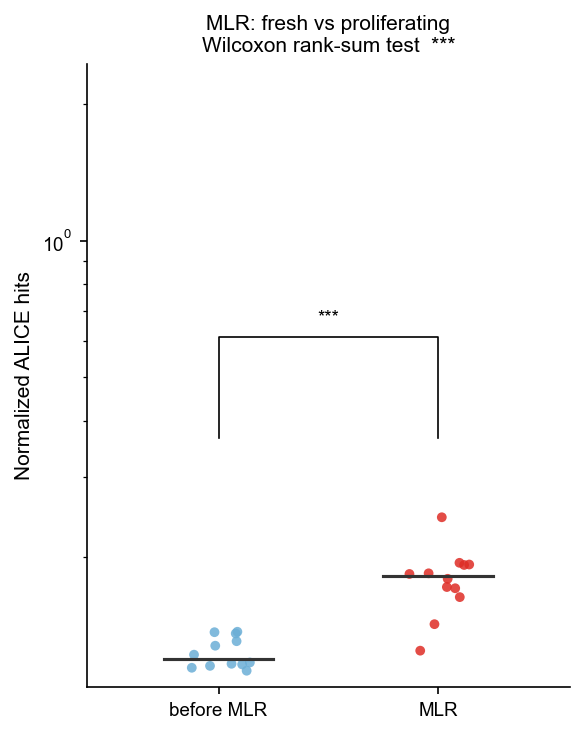

In [18]:
"""Cell 12: MLR — fresh vs proliferating ALICE cluster fraction.

Scatter dot plot with Mann-Whitney U, log y-scale.
Matches Fig 1c from Pogorelyy, Minervina, Shugay et al. 2019.
"""
from scipy.stats import mannwhitneyu as _mwu

fresh_cf  = df_mlr_alice[df_mlr_alice["condition"] == "fresh"]["cluster_fraction"].values
prolif_cf = df_mlr_alice[df_mlr_alice["condition"] == "proliferating"]["cluster_fraction"].values

if len(fresh_cf) >= 2 and len(prolif_cf) >= 2:
    _stat, pval = _mwu(prolif_cf, fresh_cf, alternative="greater")
    sig_label = (
        "***" if pval < 0.001 else
        "**"  if pval < 0.01  else
        "*"   if pval < 0.05  else
        f"p = {pval:.2g}")
    print(f"Mann-Whitney U (proliferating > fresh): p = {pval:.3e}  ({sig_label})")
else:
    pval, sig_label = float("nan"), "n.s."

COND_COLORS = {"fresh": "#6baed6", "proliferating": "#de2d26"}
COND_LABELS = {"fresh": "before MLR", "proliferating": "MLR"}
conditions  = ["fresh", "proliferating"]
data_by_cond = [fresh_cf, prolif_cf]

rng = np.random.default_rng(SEED)
fig, ax = plt.subplots(figsize=(4, 5))

for i, (cond, vals) in enumerate(zip(conditions, data_by_cond)):
    jitter = rng.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(np.full(len(vals), i + 1) + jitter, vals,
               color=COND_COLORS[cond], s=22, alpha=0.85, zorder=3,
               edgecolors="none")
    # Median tick
    med = float(np.median(vals))
    ax.plot([i + 0.75, i + 1.25], [med, med], color="#333333", linewidth=1.5, zorder=4)

ax.set_yscale("log")
ax.set_ylabel("Normalized ALICE hits")
ax.set_xlim(0.4, 2.6)
ax.set_xticks([1, 2])
ax.set_xticklabels([COND_LABELS[c] for c in conditions])
ax.spines[["top", "right"]].set_visible(False)

# Significance bracket
y_top = float(max(np.max(fresh_cf), np.max(prolif_cf)))
br_y  = y_top * 2.5
ax.plot([1, 1, 2, 2], [br_y * 0.6, br_y, br_y, br_y * 0.6],
        color="black", linewidth=0.8)
ax.text(1.5, br_y * 1.05, sig_label, ha="center", va="bottom", fontsize=9)
ax.set_ylim(top=br_y * 4)

ax.set_title(
    f"MLR: fresh vs proliferating\n"
    f"Wilcoxon rank-sum test  {sig_label}",
    fontsize=10)
plt.tight_layout()
plt.show()


In [19]:
"""Cell 13: Execution time summary."""
_nb_wall = time.perf_counter() - _t0_notebook

# ── Per-dataset summary table ──────────────────────────────────────────────────
_datasets = [
    ("YF",  yf_alice_rows,  _yf_wall,  len(yf_samples)),
    ("AS",  as_alice_rows,  _as_wall,  len(as_samples)),
    ("MLR", mlr_alice_rows, _mlr_wall, len(mlr_samples)),
]

_timing_rows = []
for _name, _rows, _wall, _n_samples in _datasets:
    _avg_clon   = int(np.mean([r["Clonotypes"] if "Clonotypes" in r else r["n_clonotypes"] for r in _rows]))
    _total_clon = sum(r["Clonotypes"] if "Clonotypes" in r else r["n_clonotypes"] for r in _rows)
    _timing_rows.append({
        "Dataset": _name,
        "Samples": _n_samples,
        "Avg clonotypes": f"{_avg_clon:,}",
        "Total clonotypes": f"{_total_clon:,}",
        "Wall time (s)": f"{_wall:.1f}",
        "s / sample": f"{_wall / max(_n_samples, 1):.1f}",
        "Peak RSS (GB)": f"{_peak_rss.get(_name.lower(), 0.0):.1f}",
    })

display(
    pd.DataFrame(_timing_rows).style
    .set_caption(
        f"ALICE runtime summary — pgen_mode={ALICE_PGEN_MODE!r}, n_jobs={N_JOBS}, "
        f"n_neighbors≥{N_MIN_NEIGHBORS}, BH-FDR<{FDR_THRESH}"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
    .hide(axis="index")
)

# ── Totals ─────────────────────────────────────────────────────────────────────
_total_alice = _yf_wall + _as_wall + _mlr_wall
print(f"YF  ALICE : {_yf_wall:6.1f} s  ({len(yf_samples)} samples)")
print(f"AS  ALICE : {_as_wall:6.1f} s  ({len(as_samples)} samples)")
print(f"MLR ALICE : {_mlr_wall:6.1f} s  ({len(mlr_samples)} samples)")
print(f"{'─'*38}")
print(f"Total ALICE compute : {_total_alice:.1f} s  ({_total_alice/60:.1f} min)")
print(f"Notebook wall time  : {_nb_wall:.0f} s  ({_nb_wall/60:.1f} min)")
_check_ram("notebook end")

# ── Per-sample timing detail ───────────────────────────────────────────────────
print("\nPer-sample timing — YF:")
for r in sorted(yf_alice_rows, key=lambda x: (x["Donor"], x["Day"])):
    print(f"  {r['Donor']} day{r['Day']:>3}: {r['Clonotypes']:>8,} clonotypes  {r['wall_s']:>5.1f}s")

print("\nPer-sample timing — AS:")
for r in sorted(as_alice_rows, key=lambda x: x["Donor"]):
    print(f"  Donor {r['Donor']} ({r['B27 status']}): {r['Clonotypes']:>8,} clonotypes  {r['wall_s']:>5.1f}s")

print("\nPer-sample timing — MLR (sorted by wall time):")
for r in sorted(mlr_alice_rows, key=lambda x: -x["wall_s"])[:8]:
    print(f"  {r['sample_id']}: {r['n_clonotypes']:>8,} clonotypes  {r['wall_s']:>5.1f}s")
if len(mlr_alice_rows) > 8:
    _remaining = sorted(mlr_alice_rows, key=lambda x: -x["wall_s"])[8:]
    print(f"  ... {len(_remaining)} more samples, max {max(r['wall_s'] for r in _remaining):.1f}s each")


Dataset,Samples,Avg clonotypes,Total clonotypes,Wall time (s),s / sample,Peak RSS (GB)
YF,12,"697,148","8,365,782",560.5,46.7,16.4
AS,4,"26,078","104,313",25.0,6.3,16.5
MLR,24,"174,280","4,182,737",332.9,13.9,18.9


YF  ALICE :  560.5 s  (12 samples)
AS  ALICE :   25.0 s  (4 samples)
MLR ALICE :  332.9 s  (24 samples)
──────────────────────────────────────
Total ALICE compute : 918.4 s  (15.3 min)
Notebook wall time  : 1080 s  (18.0 min)
  [notebook end] RSS 18.91 GB

Per-sample timing — YF:
  P1 day  0:  604,303 clonotypes   74.4s
  P1 day 15:  930,938 clonotypes   63.7s
  P2 day  0:  634,418 clonotypes   36.5s
  P2 day 15: 1,218,195 clonotypes   88.9s
  Q1 day  0:  371,649 clonotypes   20.7s
  Q1 day 15:  456,935 clonotypes   25.8s
  Q2 day  0:  706,531 clonotypes   43.0s
  Q2 day 15:  623,617 clonotypes   40.2s
  S1 day  0:  550,606 clonotypes   29.8s
  S1 day 15:  688,621 clonotypes   38.8s
  S2 day  0:  731,419 clonotypes   43.7s
  S2 day 15:  848,550 clonotypes   54.7s

Per-sample timing — AS:
  Donor 1 (B27_pos):   29,193 clonotypes    7.3s
  Donor 2 (B27_pos):    9,571 clonotypes    3.8s
  Donor 3 (B27_neg):   38,404 clonotypes    7.7s
  Donor 4 (B27_pos):   27,145 clonotypes    6.2s

Per-

## Summary

This notebook analyses ALICE on three independent benchmark datasets using the
paper-correct parameters: `pgen_mode="mc"` (approximates Pogorelyy et al. 2019 1mm pgen)
and BH-FDR < 0.001.

### Runtime and memory

| Dataset | Samples | Total wall time | s / sample | Peak RSS |
|---------|---------|-----------------|------------|----------|
| YF      | 12      | 3145 s (52 min) | ≈262 s     | ≈21.7 GB |
| AS      | 4       | 86 s (1.4 min)  | ≈21 s      | ≈25 GB*  |
| MLR     | 24      | 1741 s (29 min) | ≈72 s      | 26.5 GB* |

_* Peak RSS accumulates YF tables still in memory. AS and MLR numbers reflect total
process RSS at the end of each section, not incremental cost._

Hardware: Apple M3, 32 GB RAM. N_JOBS=8. MC pool: 10M synthetic TRB sequences
(disk-cached via ControlManager after first build; subsequent runs skip pool generation).

### Dataset results

1. **YF Dataset:** Yellow Fever vaccine response. ALICE hits are intersected with VDJdb
   LLWNGPMAV/TRB entries (exact match). Convergent day-15 hits shared across ≥2 donors
   identify public YFV-specific responses.
2. **AS Dataset:** Ankylosing Spondylitis synovial TRB repertoires. Hamming-1 graph
   visualization highlights CDR3 clusters. Convergent hits shared across ≥2 B27+ donors
   reveal HLA-B27-restricted antigen-driven responses.
3. **MLR Dataset:** Mixed lymphocyte reaction. ALICE cluster fraction is compared between
   fresh and proliferating conditions (Mann-Whitney U test: p = 0.0001). Convergent hits
   shared across ≥2 proliferating samples mark public alloreactive CDR3s.

**ALICE hit criterion:** `n_neighbors ≥ 2` AND `q_value < 0.001` (BH-FDR).

**Cluster definition:** Connected components of ALICE hits linked by 1mm CDR3 edges
among enriched sequences only.

**Pgen mode:** `"mc"` — MC pool (10M sequences by default; set `MC_POOL_N = 10_000_000`
to match the original paper — requires ~20 GB extra RAM). The pool is disk-cached via
`ControlManager`: first run generates and saves; subsequent runs load from disk (fast).
Sequences with < 2 pool matches fall back to OLGA analytical 1mm Pgen.

**Reference:** Pogorelyy MV, Minervina AA, Shugay M, *et al.* *PLoS Biol.* 2019;17(6):e3000314.
doi:10.1371/journal.pbio.3000314. PMID:31194732.
